In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('ecommerce_sales_data.csv',sep=',')
df.head()

Saving ecommerce_sales_data.csv to ecommerce_sales_data.csv


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of Dataset:
(3500, 7)

Column Names:
Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [ ]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

Duplicate Rows:
0


In [ ]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Fill missing values with mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Data Cleaning Completed")

Data Cleaning Completed


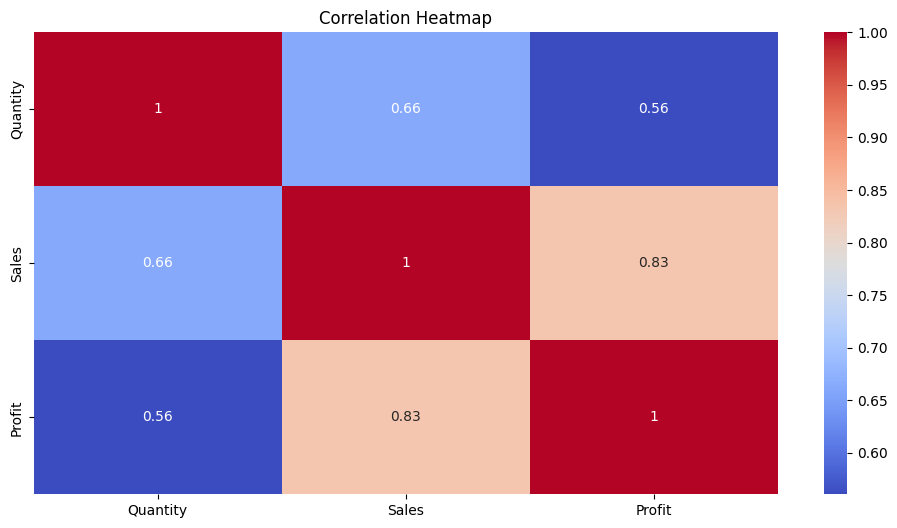

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

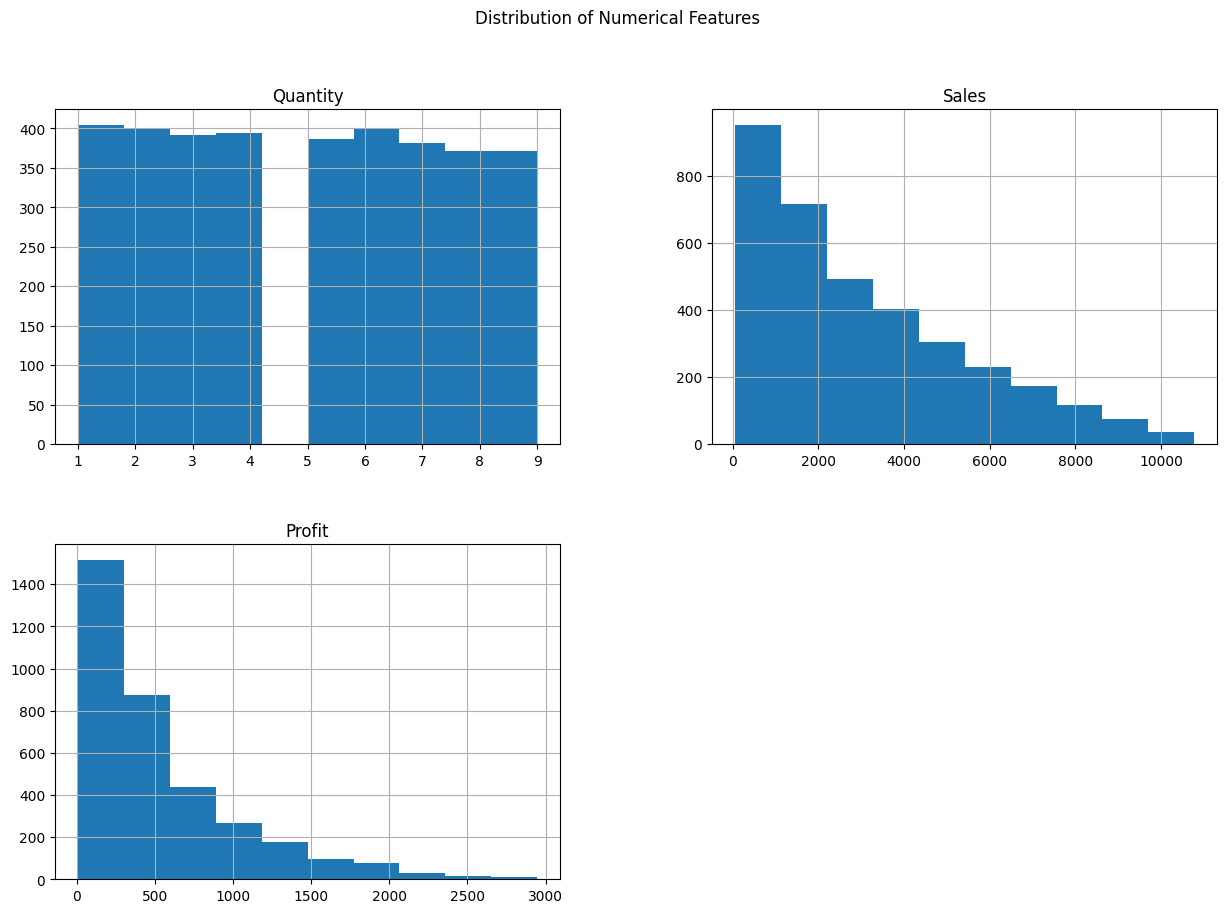

In [ ]:
df.hist(figsize=(15,10))

plt.suptitle("Distribution of Numerical Features")
plt.show()

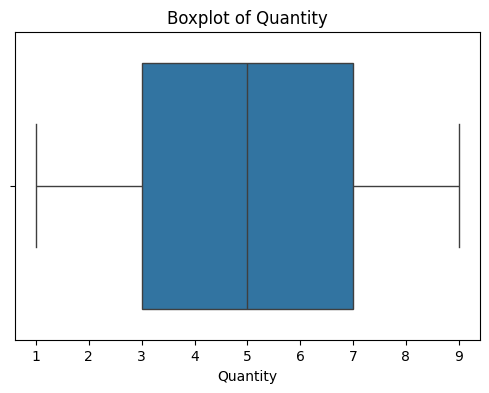

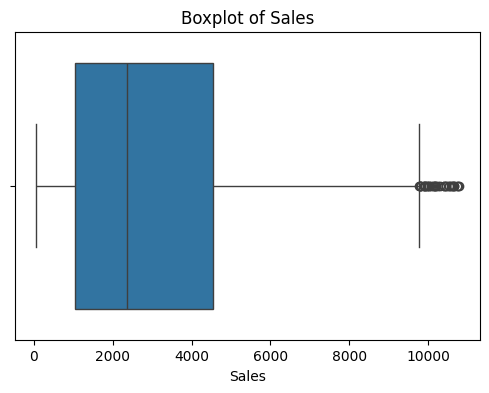

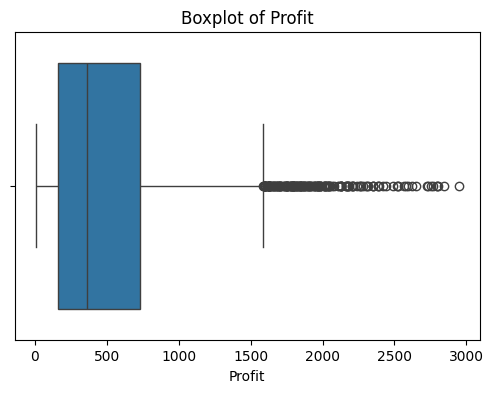

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

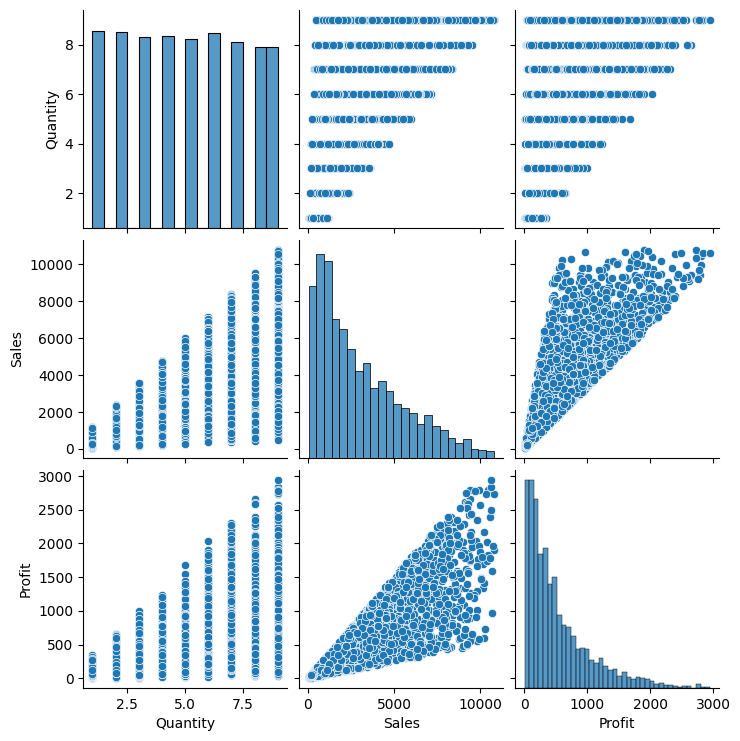

In [ ]:
sns.pairplot(df[numeric_cols])

plt.show()

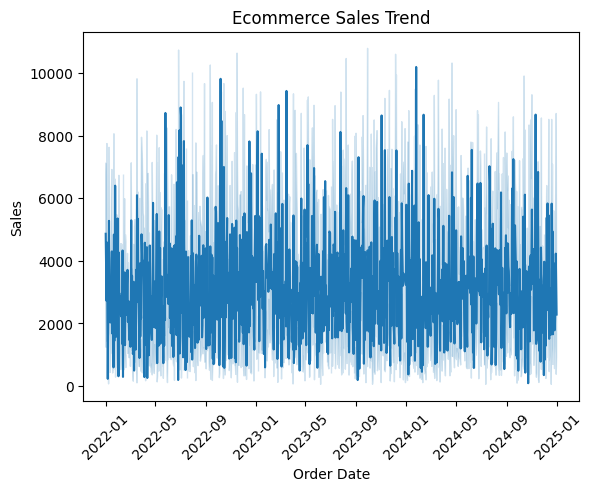

In [ ]:
# Convert date column to datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sales Trend

sns.lineplot(
    x='Order Date',
    y='Sales',
    data=df
)

plt.title("Ecommerce Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print(df.columns)

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


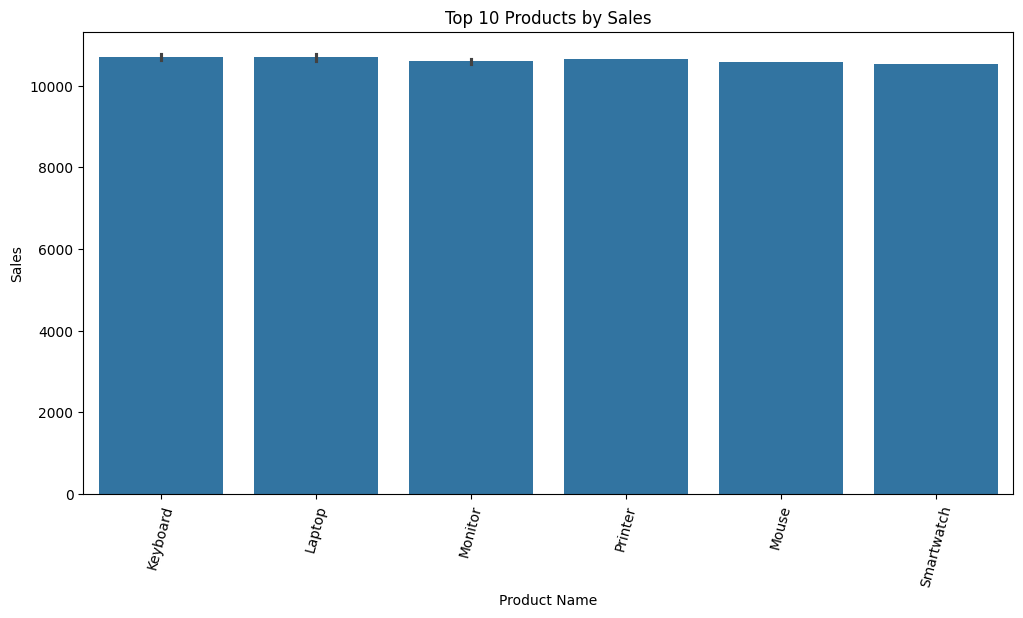

In [ ]:
# Top 10 Products by Sales

top10 = df.sort_values(
    by='Sales',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Product Name',
    y='Sales',
    data=top10
)

plt.xticks(rotation=75)

plt.title("Top 10 Products by Sales")

plt.show()

In [ ]:
df.to_csv("cleaned_global_poverty.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully
